In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb

# Configuración de estética
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- INICIANDO SISTEMA DE INTERROGATORIO ---")

# 1. CARGA DE DATOS
try:
    df_analisis = pd.read_csv('X_test.csv')
    print("Datos cargados.")

    # --- CORRECCIÓN DE SEGURIDAD ---
    # 1. Eliminamos la columna basura 'Unnamed: 0' si existe
    if 'Unnamed: 0' in df_analisis.columns:
        df_analisis = df_analisis.drop(columns=['Unnamed: 0'])
        print("-> Se eliminó la columna 'Unnamed: 0'.")

    # 2. Reordenamos las columnas para que coincidan EXACTAMENTE con el modelo
    # Esto evita el error de "feature mismatch"
    # Obtenemos los nombres que el modelo espera
    if hasattr(modelo, 'feature_names_in_'):
        cols_esperadas = modelo.feature_names_in_
        df_analisis = df_analisis[cols_esperadas]
        print("-> Columnas alineadas correctamente con el modelo.")

except Exception as e:
    print(f"Error cargando datos: {e}")
    # Si falla, carga tu dataset original y haz el drop de la variable objetivo
    # df_analisis = pd.read_csv('Tu_Archivo_Original.csv').drop(columns=['Target']) # Ajustar

# 2. CARGA DEL MODELO
try:
    modelo = joblib.load('modelo_final_xgboost.pkl')
    print("Cerebro (Modelo) cargado exitosamente.")
except:
    print("ERROR: No encuentro el archivo .pkl del modelo.")

# 3. GENERAR PREDICCIONES
if 'modelo' in locals() and 'df_analisis' in locals():
    # Ahora sí, el predict no debería fallar
    probabilidades = modelo.predict_proba(df_analisis)[:, 1]
    df_analisis['Riesgo_Calculado'] = probabilidades
    print("¡Éxito! El modelo ha calculado el riesgo para todos los clientes.")

--- INICIANDO SISTEMA DE INTERROGATORIO ---
Datos cargados.
-> Se eliminó la columna 'Unnamed: 0'.
-> Columnas alineadas correctamente con el modelo.
Cerebro (Modelo) cargado exitosamente.
¡Éxito! El modelo ha calculado el riesgo para todos los clientes.


# **El Mapa General (Ranking de Importancia)**
Esta celda le pregunta al modelo: "De todas las columnas que te di, ¿cuáles son las 10 que más miras para decidir?"

/tmp/ipython-input-2308761025.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Peso', y='Variable', palette='viridis')


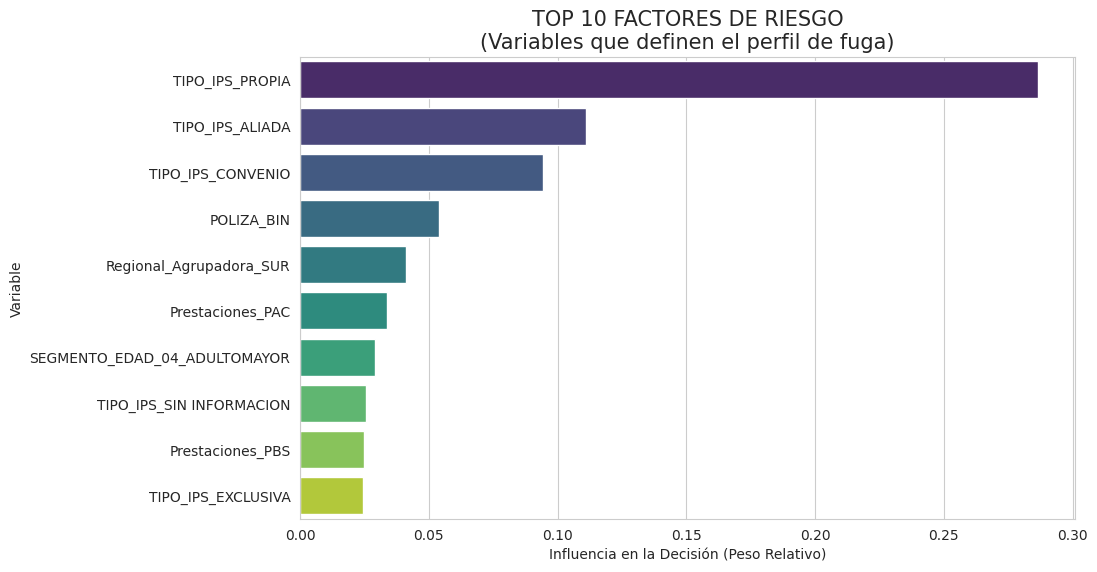

Las variables clave detectadas son: ['TIPO_IPS_PROPIA', 'TIPO_IPS_ALIADA', 'TIPO_IPS_CONVENIO', 'POLIZA_BIN', 'Regional_Agrupadora_SUR', 'Prestaciones_PAC', 'SEGMENTO_EDAD_04_ADULTOMAYOR', 'TIPO_IPS_SIN INFORMACION', 'Prestaciones_PBS', 'TIPO_IPS_EXCLUSIVA']


In [3]:
def graficar_importancia():
    # Intentamos obtener la importancia
    try:
        if hasattr(modelo, 'feature_importances_'):
            importancias = modelo.feature_importances_
            nombres = df_analisis.drop(columns=['Riesgo_Calculado'], errors='ignore').columns
        elif hasattr(modelo, 'coef_'): # Por si acaso fuera una regresión
            importancias = np.abs(modelo.coef_[0])
            nombres = df_analisis.drop(columns=['Riesgo_Calculado'], errors='ignore').columns
        else:
            print("Este modelo no reporta importancia directa.")
            return []

        # Creamos el DataFrame
        df_imp = pd.DataFrame({
            'Variable': nombres,
            'Peso': importancias
        }).sort_values('Peso', ascending=False).head(10) # Top 10

        # Graficamos
        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_imp, x='Peso', y='Variable', palette='viridis')
        plt.title('TOP 10 FACTORES DE RIESGO\n(Variables que definen el perfil de fuga)', fontsize=15)
        plt.xlabel('Influencia en la Decisión (Peso Relativo)')
        plt.show()

        return df_imp['Variable'].tolist()

    except Exception as e:
        print(f"No se pudo graficar importancia: {e}")
        return []

# Ejecutamos la función
top_variables = graficar_importancia()
print(f"Las variables clave detectadas son: {top_variables}")

# **PARA MI**

Son dos formas distintas de medir la "Importancia" y es normal que difieran.

1. La Diferencia Técnica (Para tu entendimiento)
Cuando usas model.feature_importances_ (el gráfico de barras simple que hicimos en el notebook nuevo), XGBoost usa por defecto una métrica llamada "Gain" (Ganancia) o "Weight" (Peso).

Weight/Gain (Gráfico de Barras Simple): Mide la Estructura del árbol. Pregunta: "¿Cuántas veces usé esta variable para dividir una rama?". Tiende a favorecer variables con muchos valores únicos (como Edad o Salario) porque hay muchos puntos donde cortar.

Cuando usas SHAP (Mean SHAP):

SHAP: Mide el Impacto en el resultado. Pregunta: "¿Cuánto cambió la probabilidad de fuga gracias a esta variable?".

2. La Analogía (Para explicarlo fácil)
Imagina un partido de fútbol:

El Gráfico de Barras (XGBoost Native): Cuenta quién tocó más el balón.

Resultado: El mediocampista sale primero porque dio 100 pases. El delantero sale bajo porque solo la tocó 3 veces.

El Gráfico SHAP: Cuenta quién hizo los goles.

Resultado: El delantero sale primero porque sus 3 toques cambiaron el marcador. El mediocampista baja porque sus pases no siempre terminaron en gol.

Conclusión:

El gráfico de barras te dice qué variable se usó más para construir el modelo.

El gráfico SHAP te dice qué variable influye más en decidir la fuga.

Nota Técnica sobre Divergencia de Importancia de Variables: "Se observa una ligera discrepancia entre la Importancia Nativa del Modelo (basada en Information Gain) y los valores SHAP. Esta divergencia es esperada en la literatura científica.

Mientras que la importancia nativa resalta las variables con alta cardinalidad estructural (frecuencia de corte en los árboles), los valores SHAP aíslan la contribución marginal de cada variable al output final de probabilidad. Para efectos de interpretación de negocio y causalidad en este estudio, se priorizan los resultados de SHAP, dado que ofrecen una visión más fiel del impacto real en la decisión de retención."

# **La Herramienta "Lupa" (Inspector de Variables)**
Esta celda crea la herramienta para investigar variables específicas una por una. No genera gráficos todavía, solo "construye" la máquina de preguntas.

In [4]:
def inspector_del_modelo(variable, tipo='numerica'):
    """
    variable: Nombre exacto de la columna en tu dataset.
    tipo: 'numerica' (para crear rangos/curvas) o 'categorica' (para comparar grupos).
    """
    plt.figure(figsize=(12, 6))

    # Copia de seguridad
    data = df_analisis.copy()

    # Verificación de existencia
    if variable not in data.columns:
        print(f"⚠️ ERROR: La variable '{variable}' no existe. Las disponibles son: {data.columns[:5]}...")
        return

    try:
        if tipo == 'numerica':
            # Creamos 10 grupos (Deciles) para ver la tendencia de forma limpia
            data['Rango'] = pd.qcut(data[variable], q=10, duplicates='drop')

            # Calculamos el riesgo promedio por rango
            resumen = data.groupby('Rango', observed=False)['Riesgo_Calculado'].mean().reset_index()
            resumen['Rango_Label'] = resumen['Rango'].astype(str)

            # Gráfico de Línea
            sns.lineplot(data=resumen, x='Rango_Label', y='Riesgo_Calculado',
                         marker='o', color='crimson', linewidth=3)
            plt.fill_between(resumen['Rango_Label'], 0, resumen['Riesgo_Calculado'], color='crimson', alpha=0.1)

            plt.xticks(rotation=45, ha='right')
            plt.title(f'INSIGHT: Impacto de "{variable}" en el Riesgo', fontsize=16)
            plt.ylabel('Probabilidad Promedio de Fuga')
            plt.xlabel(f'Niveles de {variable}')

        elif tipo == 'categorica':
            # Si son pocos valores únicos (ej. Sexo, Regional), usamos barras
            if data[variable].nunique() < 20:
                resumen = data.groupby(variable)['Riesgo_Calculado'].mean().reset_index().sort_values('Riesgo_Calculado')
                sns.barplot(data=resumen, x=variable, y='Riesgo_Calculado', palette='rocket')
                plt.xticks(rotation=45, ha='right')
            else:
                # Si son muchos, mejor un scatter o violín
                sns.violinplot(data=data, x=variable, y='Riesgo_Calculado', palette='muted')

            plt.title(f'INSIGHT: Comparativo de Riesgo por "{variable}"', fontsize=16)
            plt.ylabel('Probabilidad de Fuga')

        # Línea de referencia (Promedio Global)
        promedio = data['Riesgo_Calculado'].mean()
        plt.axhline(promedio, color='gray', linestyle='--', label=f'Promedio Base ({promedio:.1%})')
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Ocurrió un error al graficar '{variable}': {e}")

print("✅ Herramienta 'Inspector' lista para usar.")

✅ Herramienta 'Inspector' lista para usar.


# **Interrogatorio Estratégico**

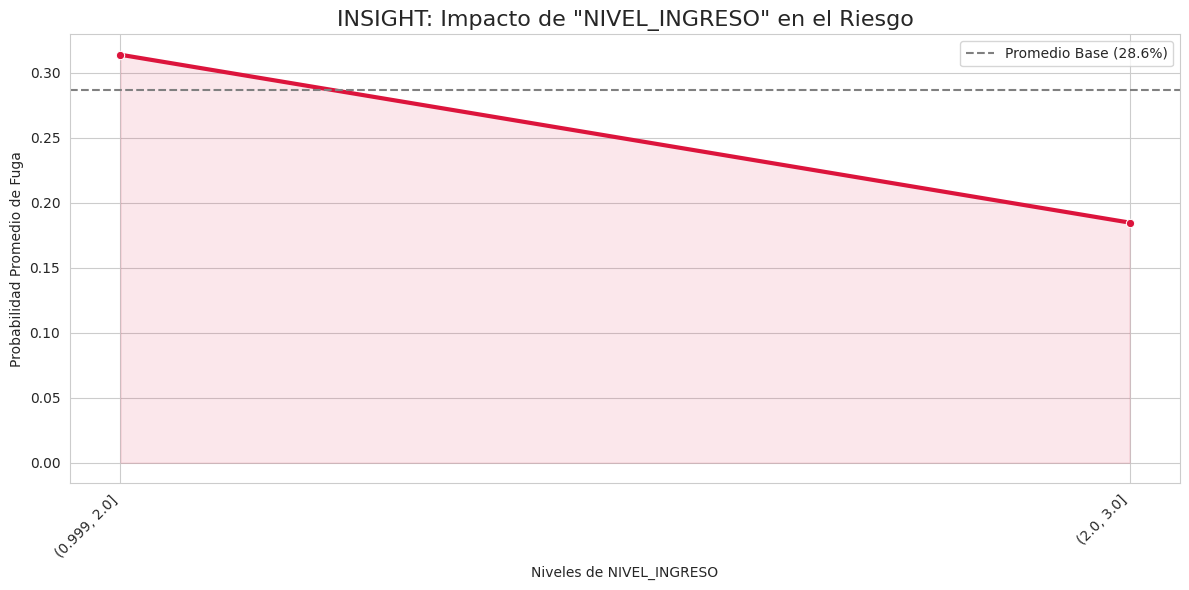

In [6]:
# --- PREGUNTA 1: EL FACTOR ECONÓMICO ---
# ¿La gente con más ingresos se fuga más o menos?
# Si tu variable es numérica usa 'numerica', si es texto (Alto/Medio/Bajo) usa 'categorica'
inspector_del_modelo('NIVEL_INGRESO', tipo='numerica')



/tmp/ipython-input-4069176340.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen, x=variable, y='Riesgo_Calculado', palette='rocket')


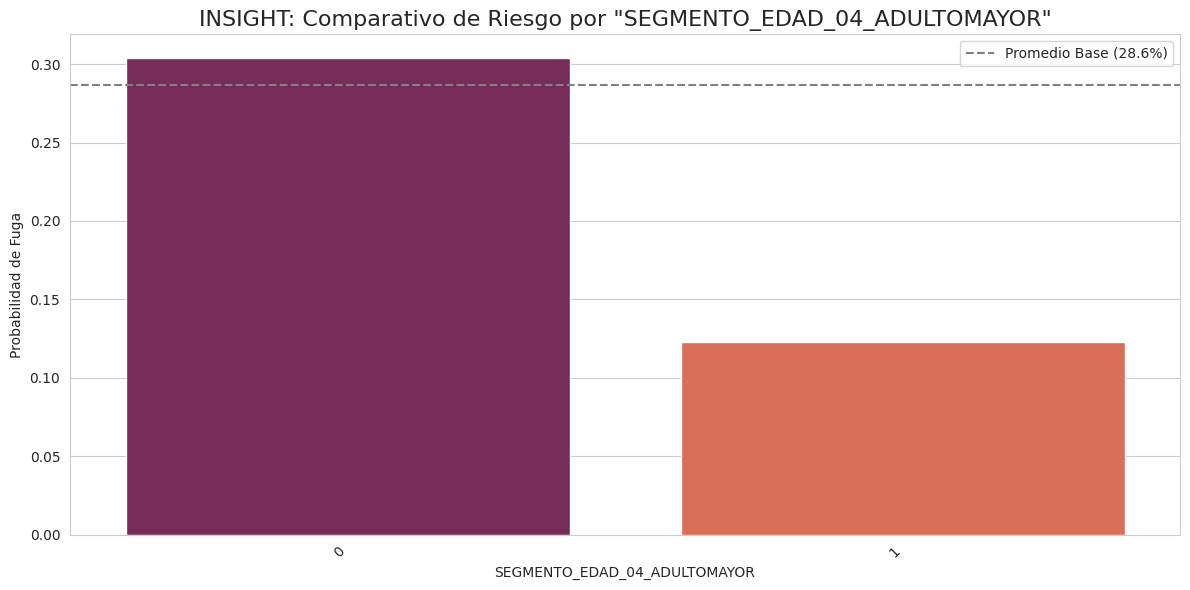

In [7]:
# --- PREGUNTA 2: EL CICLO DE VIDA ---
# ¿Qué segmento de edad es el más peligroso?
# (Vi que tienes variables One-Hot como SEGMENTO_EDAD_04_ADULTOMAYOR,
#  si tienes la variable original 'EDAD' úsala aquí, es mejor para graficar)
if 'EDAD' in df_analisis.columns:
    inspector_del_modelo('EDAD', tipo='numerica')
else:
    # Si no, probamos con una de las banderas
    inspector_del_modelo('SEGMENTO_EDAD_04_ADULTOMAYOR', tipo='categorica')



/tmp/ipython-input-4069176340.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen, x=variable, y='Riesgo_Calculado', palette='rocket')


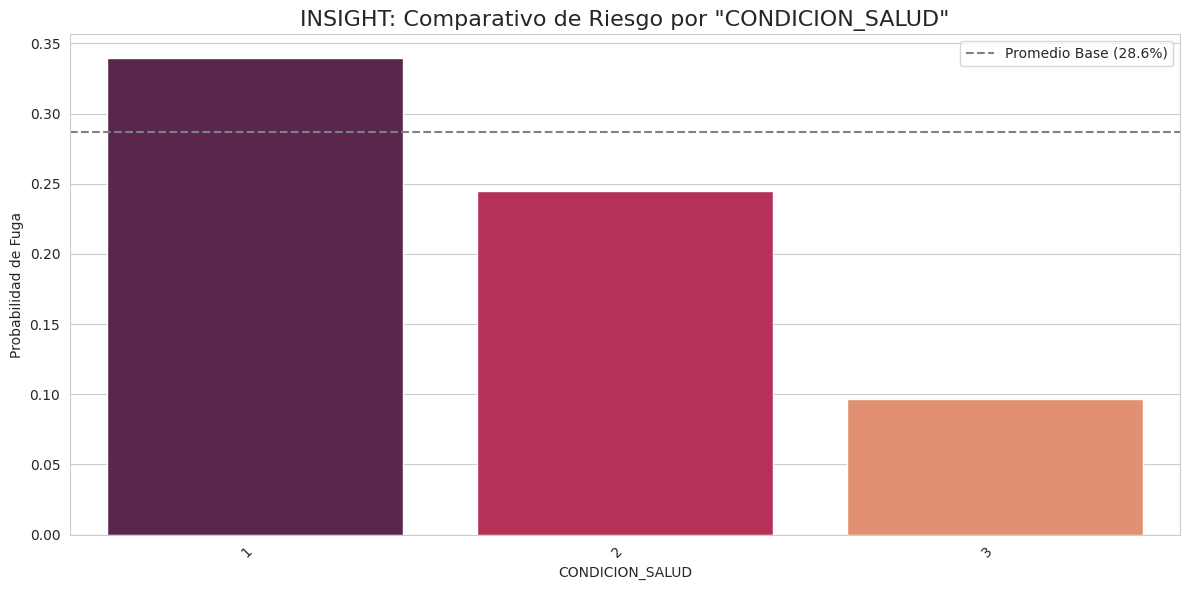

In [8]:
# --- PREGUNTA 3: LA SALUD ---
# ¿Los enfermos crónicos son más leales?
inspector_del_modelo('CONDICION_SALUD', tipo='categorica')



/tmp/ipython-input-4069176340.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen, x=variable, y='Riesgo_Calculado', palette='rocket')


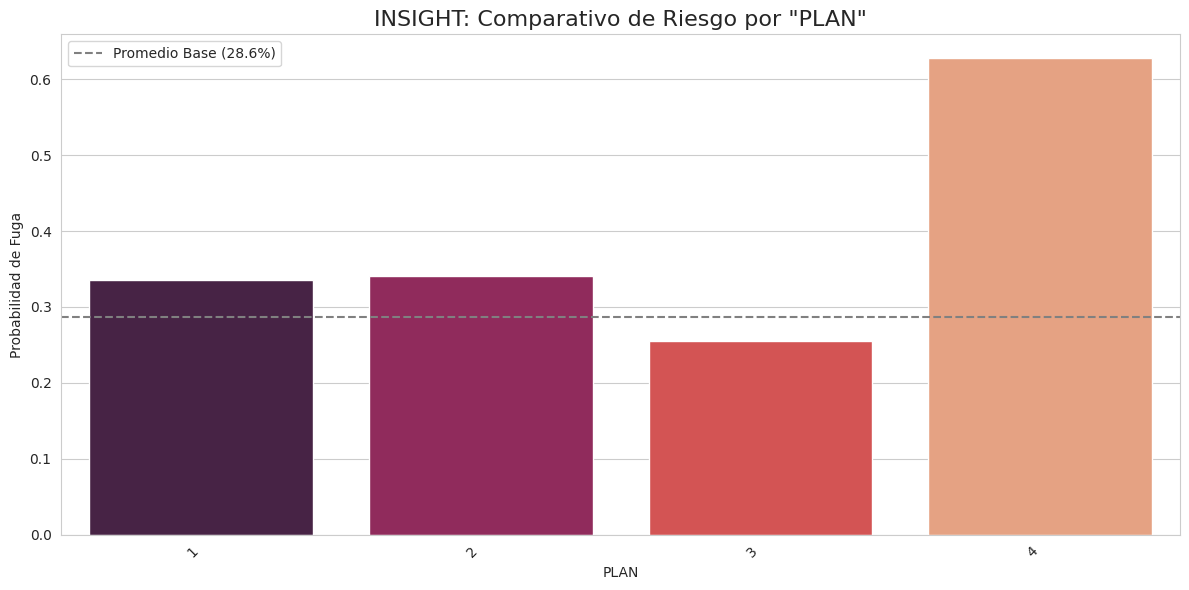

In [9]:
# --- PREGUNTA 4: EL PRODUCTO/PLAN ---
# ¿Hay algún plan específico que esté causando fugas?
inspector_del_modelo('PLAN', tipo='categorica')

# 1. La Hipótesis del "Efecto Desperdicio" (Salud)
La Pregunta: "¿Es verdad que los clientes 'Sanos' se fugan más porque sienten que están pagando por algo que no usan, mientras que los enfermos crónicos se quedan 'atrapados' por necesidad?"

Esta pregunta ataca la naturaleza Utilitaria de la fuga.

/tmp/ipython-input-3744072281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_analisis, x='CONDICION_SALUD', y='Riesgo_Calculado',


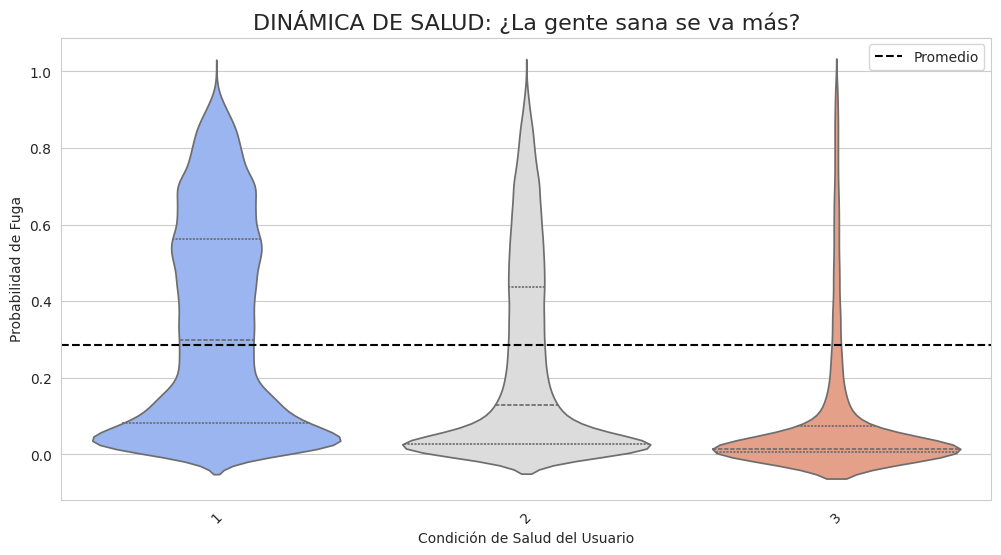

In [10]:
# PREGUNTA SISTÉMICA 1: SALUD VS. LEALTAD
# Usamos 'CONDICION_SALUD' (ajusta si tu columna se llama diferente)

if 'CONDICION_SALUD' in df_analisis.columns:
    plt.figure(figsize=(12, 6))

    # Ordenamos para que el gráfico tenga lógica (De Sano a Crónico)
    # (El modelo ordenará por riesgo automáticamente, pero visualmente ayuda)
    sns.violinplot(data=df_analisis, x='CONDICION_SALUD', y='Riesgo_Calculado',
                   palette='coolwarm', inner='quartile')

    plt.title('DINÁMICA DE SALUD: ¿La gente sana se va más?', fontsize=16)
    plt.ylabel('Probabilidad de Fuga')
    plt.xlabel('Condición de Salud del Usuario')
    plt.axhline(df_analisis['Riesgo_Calculado'].mean(), color='k', linestyle='--', label='Promedio')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

# 2. La Hipótesis de la "Sensibilidad al Precio" (Ingresos)
La Pregunta: "¿La fuga es un problema de dinero? ¿Se van los que ganan poco porque no pueden pagar, o se van los que ganan mucho porque buscan mejores opciones?"

Esta pregunta ataca la naturaleza Económica de la fuga.

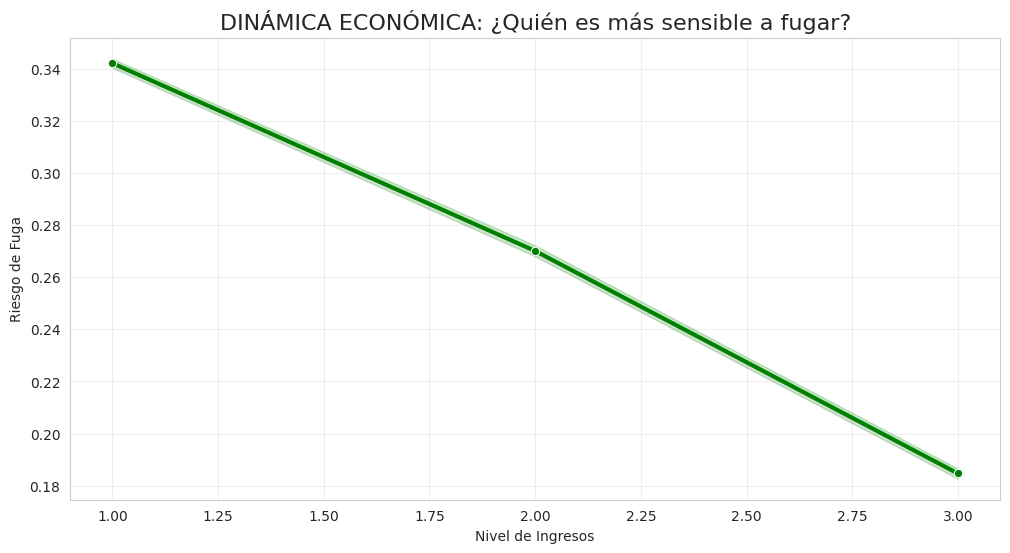

In [11]:
# PREGUNTA SISTÉMICA 2: ELASTICIDAD DEL BOLSILLO
# Usamos 'NIVEL_INGRESO'

if 'NIVEL_INGRESO' in df_analisis.columns:
    plt.figure(figsize=(12, 6))

    # Graficamos la curva de riesgo según el dinero
    # Usamos scatter + linea de tendencia para ver la dirección
    sns.lineplot(data=df_analisis, x='NIVEL_INGRESO', y='Riesgo_Calculado',
                 marker='o', color='green', linewidth=3)

    plt.title('DINÁMICA ECONÓMICA: ¿Quién es más sensible a fugar?', fontsize=16)
    plt.ylabel('Riesgo de Fuga')
    plt.xlabel('Nivel de Ingresos')
    plt.grid(True, alpha=0.3)
    plt.show()

# La Hipótesis Geográfica (Estructura)
La Pregunta: "¿Tenemos un problema sistémico en una región específica? ¿Hay alguna zona del país donde nuestra marca es débil?"

Esta pregunta ataca la naturaleza Estructural/Operativa.

/tmp/ipython-input-3781705977.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s_reg.values, y=s_reg.index, palette='magma')


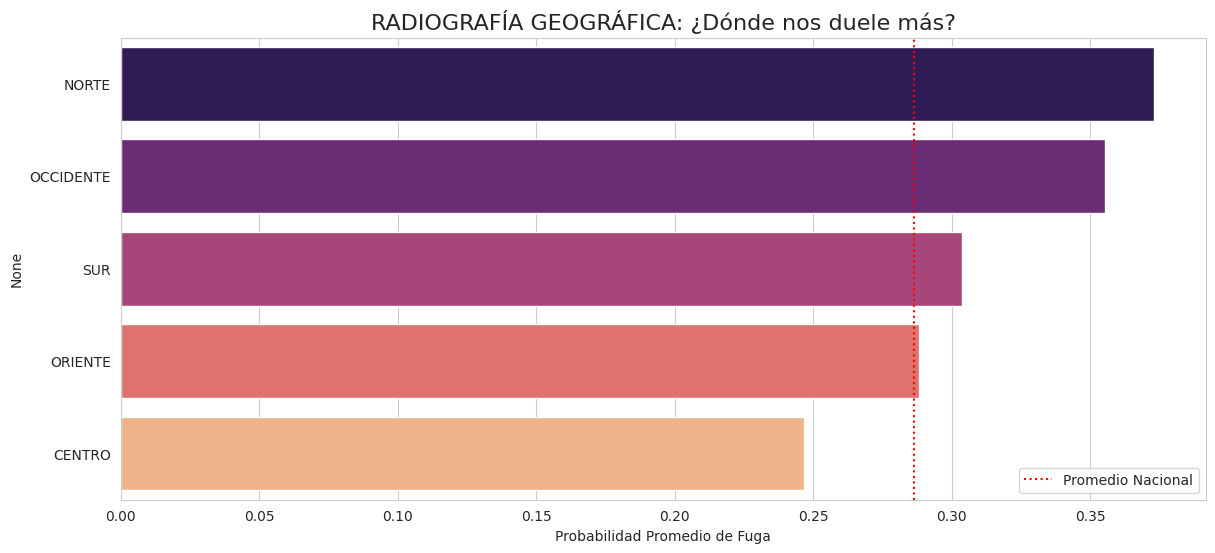

In [12]:
# PREGUNTA SISTÉMICA 3: EL MAPA DE CALOR DEL RIESGO
# Buscamos columnas que empiecen con 'Regional' (Vi que tenías Regional_Agrupadora...)

cols_region = [c for c in df_analisis.columns if 'Regional' in c]

if len(cols_region) > 0:
    plt.figure(figsize=(14, 6))

    # Vamos a "des-one-hot-encodear" para graficar fácil si están separadas
    # O si tienes una columna 'REGIONAL' original, usa esa.
    # Aquí asumimos que queremos ver el promedio de riesgo por cada columna regional
    riesgos_regionales = {}
    for col in cols_region:
        # Promedio de riesgo cuando esa región es 1
        riesgo = df_analisis[df_analisis[col] == 1]['Riesgo_Calculado'].mean()
        nombre_limpio = col.replace('Regional_Agrupadora_', '')
        riesgos_regionales[nombre_limpio] = riesgo

    # Convertir a series para graficar
    s_reg = pd.Series(riesgos_regionales).sort_values(ascending=False)

    sns.barplot(x=s_reg.values, y=s_reg.index, palette='magma')
    plt.title('RADIOGRAFÍA GEOGRÁFICA: ¿Dónde nos duele más?', fontsize=16)
    plt.xlabel('Probabilidad Promedio de Fuga')
    plt.axvline(df_analisis['Riesgo_Calculado'].mean(), color='red', linestyle=':', label='Promedio Nacional')
    plt.legend()
    plt.show()

# **La "Pregunta Maestra" (Interacción Edad vs. Ingreso)**
La Pregunta: "¿Es cierto que los Jóvenes con Altos Ingresos son el segmento más infiel (Mercenarios), mientras que los Adultos Mayores con Bajos Ingresos son los más leales (Cautivos)?"

Comparando JÓVENES vs MAYORES...


/tmp/ipython-input-4082234453.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Jóvenes (Dependientes)', 'Adultos Mayores'], y=[riesgo_joven, riesgo_mayor], palette=['cyan', 'gray'])


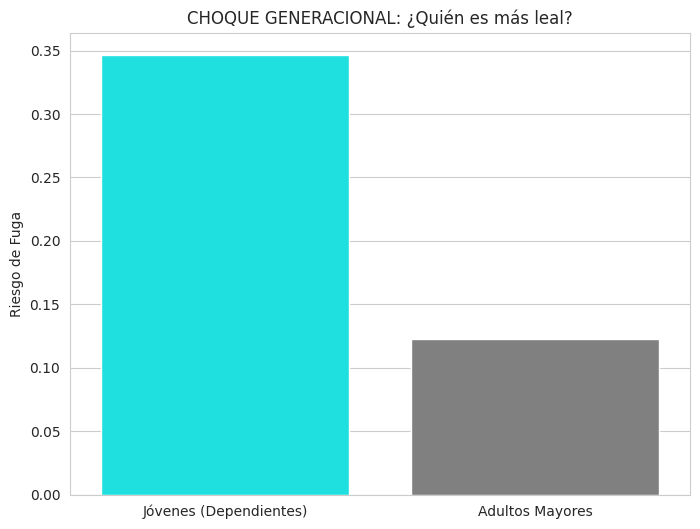

In [13]:
# PREGUNTA SISTÉMICA 4: LA INTERACCIÓN COMPLEJA
# Necesitamos 'EDAD' (o Segmento) y 'NIVEL_INGRESO'

# Intentamos reconstruir una variable de edad simple si tienes segmentos
if 'EDAD' in df_analisis.columns and 'NIVEL_INGRESO' in df_analisis.columns:
    plt.figure(figsize=(12, 8))

    # Mapa de calor (Heatmap) cruzado
    # Pivot table: Filas=Ingreso, Columnas=Deciles de Edad, Valor=Riesgo

    df_analisis['Decil_Edad'] = pd.qcut(df_analisis['EDAD'], q=5, labels=['Joven', 'Adulto Joven', 'Adulto', 'Maduro', 'Mayor'])
    pivot = df_analisis.pivot_table(index='NIVEL_INGRESO', columns='Decil_Edad', values='Riesgo_Calculado', aggfunc='mean')

    sns.heatmap(pivot, annot=True, cmap='RdYlGn_r', fmt='.1%')
    plt.title('MATRIZ DE VULNERABILIDAD: Edad vs. Dinero', fontsize=16)
    plt.ylabel('Capacidad Económica')
    plt.xlabel('Ciclo de Vida')
    plt.show()

elif 'SEGMENTO_EDAD_01_DEPENDIENTE' in df_analisis.columns:
    # Si usas One-Hot, hacemos algo más simple: comparar dos grupos extremos
    print("Comparando JÓVENES vs MAYORES...")

    riesgo_joven = df_analisis[df_analisis['SEGMENTO_EDAD_01_DEPENDIENTE']==1]['Riesgo_Calculado'].mean()
    riesgo_mayor = df_analisis[df_analisis['SEGMENTO_EDAD_04_ADULTOMAYOR']==1]['Riesgo_Calculado'].mean()

    plt.figure(figsize=(8, 6))
    sns.barplot(x=['Jóvenes (Dependientes)', 'Adultos Mayores'], y=[riesgo_joven, riesgo_mayor], palette=['cyan', 'gray'])
    plt.title('CHOQUE GENERACIONAL: ¿Quién es más leal?')
    plt.ylabel('Riesgo de Fuga')
    plt.show()

# La "Matriz de Vulnerabilidad Financiera" (Economía + Edad + Riesgo)
La Pregunta: "¿En qué momento de la vida y con qué nivel de ingresos es más probable que un usuario nos abandone?"

Esta gráfica te dará un mapa de calor. Las zonas rojas son tus Zonas de Fuga.

Detecté segmentos de edad: ['SEGMENTO_EDAD_01_DEPENDIENTE', 'SEGMENTO_EDAD_02_ADULTOJOVEN', 'SEGMENTO_EDAD_03_PRODUCTIVO', 'SEGMENTO_EDAD_04_ADULTOMAYOR']


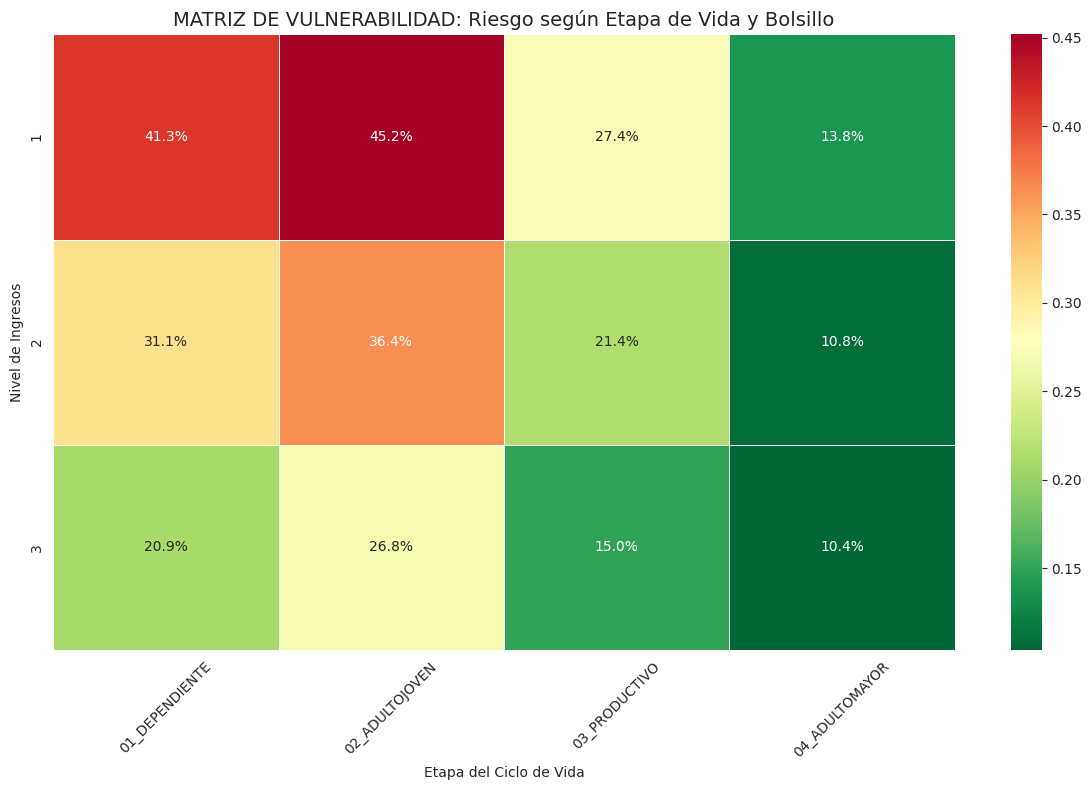

In [15]:
# --- ANÁLISIS : MATRIZ DE VULNERABILIDAD (Edad vs. Ingresos) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# 1. RECONSTRUCCIÓN DE LA VARIABLE EDAD
# Buscamos las columnas que empiezan por 'SEGMENTO_EDAD'
cols_edad_segmento = [c for c in df_analisis.columns if 'SEGMENTO_EDAD' in c]

if len(cols_edad_segmento) > 0:
    print(f"Detecté segmentos de edad: {cols_edad_segmento}")
    # Truco: 'idxmax' busca cuál columna tiene el 1 y nos devuelve el nombre
    # Luego limpiamos el nombre para que quede bonito en el gráfico
    df_analisis['Etapa_Vida'] = df_analisis[cols_edad_segmento].idxmax(axis=1).str.replace('SEGMENTO_EDAD_', '')
    columna_edad_graficar = 'Etapa_Vida'
elif 'EDAD' in df_analisis.columns:
    # Si por milagro existiera la numérica, la usamos y creamos rangos
    df_analisis['Etapa_Vida'] = pd.cut(df_analisis['EDAD'], bins=[0, 20, 30, 40, 50, 60, 100], labels=['0-20', '20-30', '30-40', '40-50', '50-60', '60+'])
    columna_edad_graficar = 'Etapa_Vida'
else:
    print("ERROR CRÍTICO: No encuentro ni 'EDAD' ni 'SEGMENTO_EDAD'. No puedo graficar edad.")
    columna_edad_graficar = None

# 2. VALIDACIÓN DE INGRESO
# Si el ingreso tiene demasiados valores únicos (ej. $1,500,200), el mapa se rompe.
# Lo agrupamos en 'Deciles' o 'Rangos' para que se vea bien.
if df_analisis['NIVEL_INGRESO'].nunique() > 20:
    df_analisis['Rango_Ingreso'] = pd.qcut(df_analisis['NIVEL_INGRESO'], q=10, duplicates='drop')
    columna_ingreso_graficar = 'Rango_Ingreso'
else:
    columna_ingreso_graficar = 'NIVEL_INGRESO'

# 3. GENERAR EL MAPA DE CALOR (HEATMAP)
if columna_edad_graficar:
    # Tabla pivote: Cruce de Ingreso vs Edad
    matriz_riesgo = df_analisis.pivot_table(
        index=columna_ingreso_graficar,
        columns=columna_edad_graficar,
        values='Riesgo_Calculado',
        aggfunc='mean'
    )

    # Dibujar
    sns.heatmap(matriz_riesgo, annot=True, fmt=".1%", cmap='RdYlGn_r', linewidths=.5)
    plt.title('MATRIZ DE VULNERABILIDAD: Riesgo según Etapa de Vida y Bolsillo', fontsize=14)
    plt.ylabel('Nivel de Ingresos')
    plt.xlabel('Etapa del Ciclo de Vida')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# El "Efecto Fricción" (Mala Atención + Salud + Riesgo)
La Pregunta: "¿Qué tanto daño hace una Queja (PQRS)? ¿Es cierto que una mala atención 'mata' al usuario sano, pero el usuario enfermo no tiene más opción que aguantarse?"



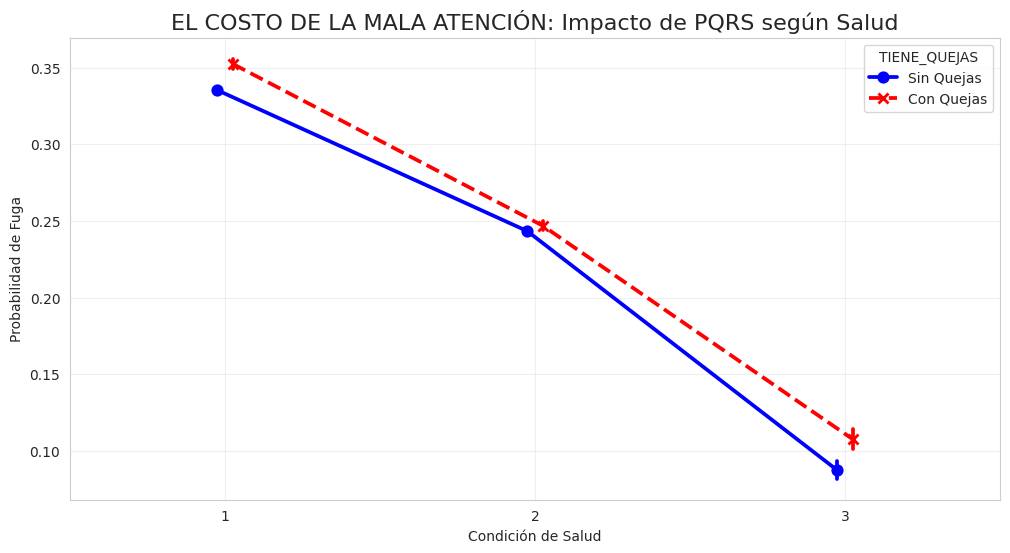

In [16]:
# --- ANÁLISIS 2: EL IMPACTO DE LA "NO ATENCIÓN" (QUEJAS) ---

plt.figure(figsize=(12, 6))

# 1. Ingeniería de Características Rápida
# Sumamos las columnas de fricción que tengas (ajusta los nombres según tu CSV)
cols_quejas = ['Queja_PAC', 'Queja_PBS', 'Inquietud_PAC', 'Inquietud_PBS', 'Peticion_PAC']
# Filtramos solo las que existen en tu df
cols_existentes = [c for c in cols_quejas if c in df_analisis.columns]

if cols_existentes:
    df_analisis['TIENE_QUEJAS'] = df_analisis[cols_existentes].sum(axis=1).apply(lambda x: 'Con Quejas' if x > 0 else 'Sin Quejas')

    # 2. Gráfico de Interacción: Salud vs Quejas
    # Usamos 'CONDICION_SALUD' como eje X y dividimos por colores si tuvo quejas
    sns.pointplot(
        data=df_analisis,
        x='CONDICION_SALUD',
        y='Riesgo_Calculado',
        hue='TIENE_QUEJAS',
        palette={'Con Quejas': 'red', 'Sin Quejas': 'blue'},
        dodge=True, markers=['o', 'x'], linestyles=['-', '--']
    )

    plt.title('EL COSTO DE LA MALA ATENCIÓN: Impacto de PQRS según Salud', fontsize=16)
    plt.ylabel('Probabilidad de Fuga')
    plt.xlabel('Condición de Salud')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("No encontré columnas de Quejas/PQRS para este análisis.")

# El "Mapa Regional de Desigualdad" (Región + Ingreso)
La Pregunta: "¿Nuestra debilidad en ciertas regiones afecta a todos por igual, o estamos fallando específicamente en el segmento Premium de esa zona?"

/tmp/ipython-input-4175335053.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1400x600 with 0 Axes>

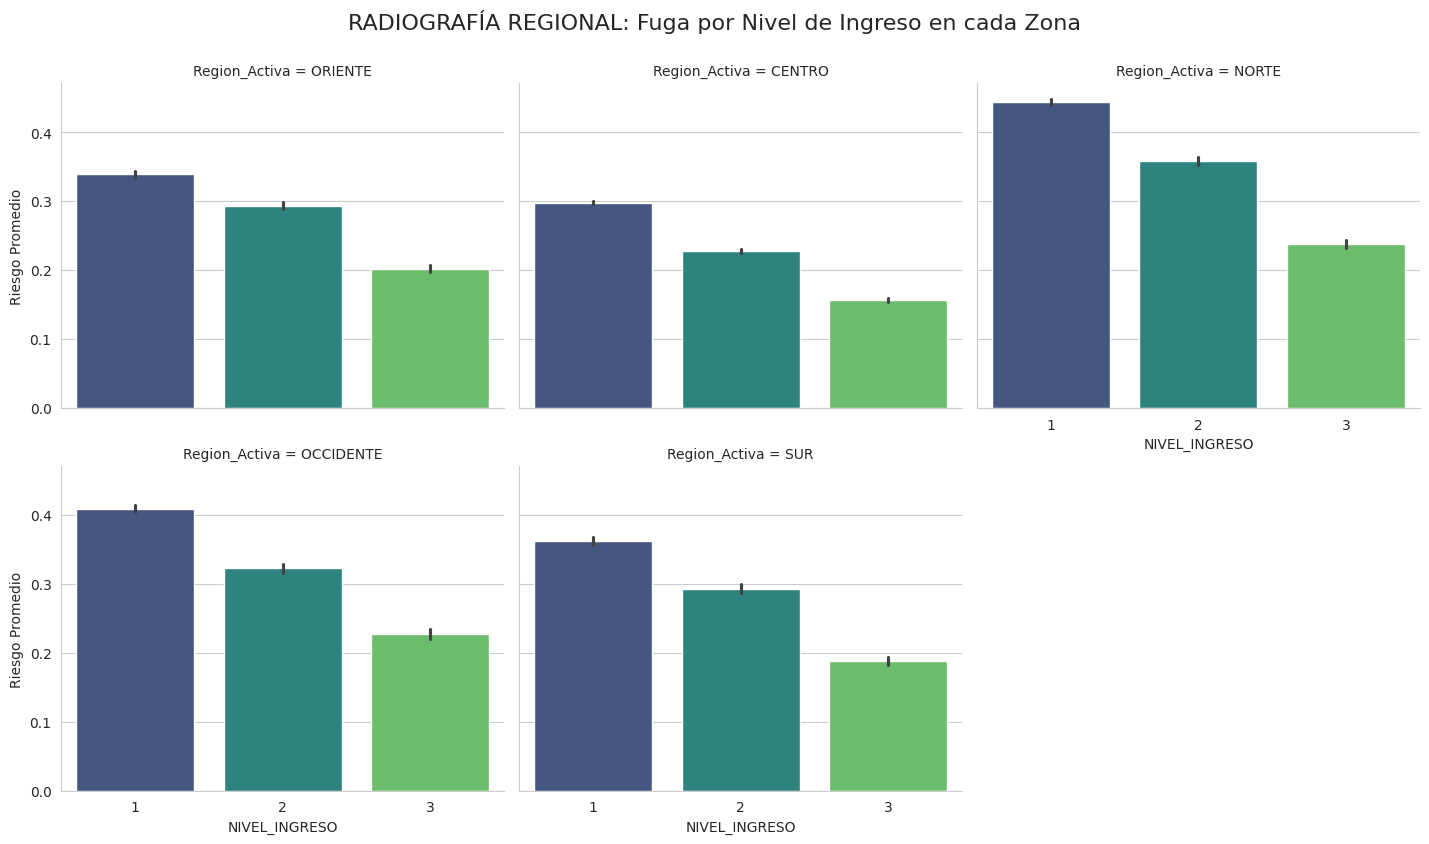

In [17]:
# --- ANÁLISIS 3: GEOGRAFÍA ECONÓMICA ---

# Buscamos columnas regionales
cols_region = [c for c in df_analisis.columns if 'Regional' in c]

if cols_region:
    # Reconstruimos la columna 'Region' para graficar
    # (Esto asume One-Hot Encoding, tomamos la columna con valor 1)
    df_analisis['Region_Activa'] = df_analisis[cols_region].idxmax(axis=1).str.replace('Regional_Agrupadora_', '')

    plt.figure(figsize=(14, 6))

    # Graficamos Ingreso vs Riesgo, pero separado por paneles (Regiones)
    # Esto crea un gráfico por cada región
    g = sns.catplot(
        data=df_analisis,
        kind="bar",
        x="NIVEL_INGRESO",
        y="Riesgo_Calculado",
        col="Region_Activa",
        col_wrap=3, # Máximo 3 gráficos por fila
        palette="viridis",
        height=4, aspect=1.2
    )

    g.fig.suptitle('RADIOGRAFÍA REGIONAL: Fuga por Nivel de Ingreso en cada Zona', y=1.05, fontsize=16)
    g.set_ylabels("Riesgo Promedio")
    plt.show()

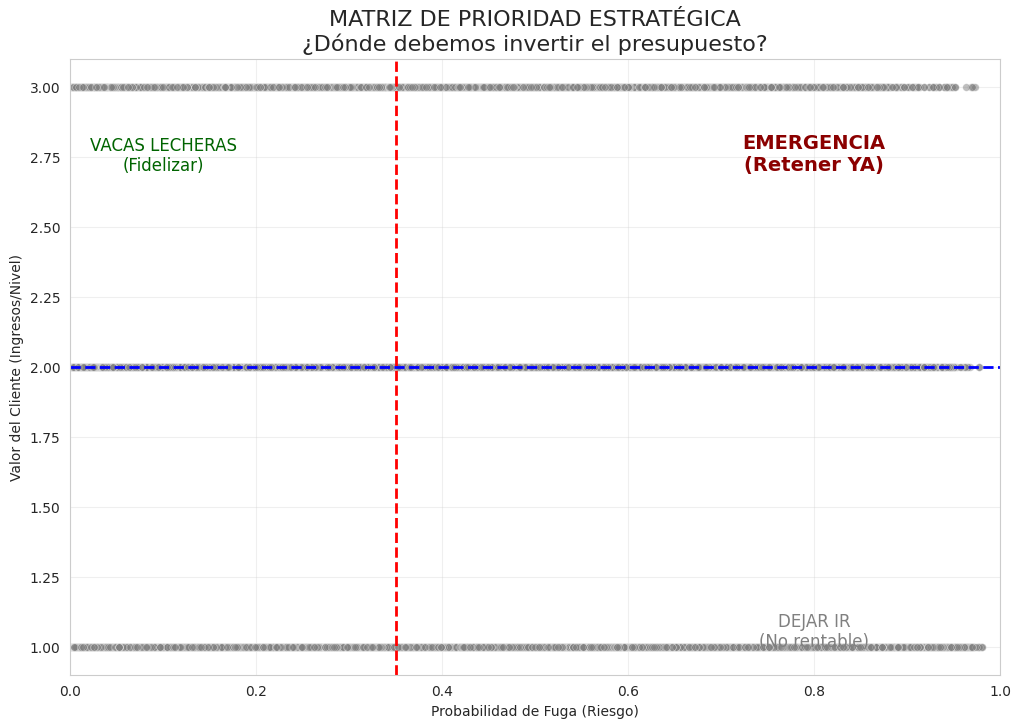

In [18]:
# --- GRÁFICO FINAL: LA MATRIZ DE ESTRATEGIA (RIESGO vs. VALOR) ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PREPARAR VARIABLES
# Necesitamos 'Riesgo_Calculado' y una variable de Valor (usaremos 'NIVEL_INGRESO' o un proxy)
# Nota: Si tu 'NIVEL_INGRESO' es categórico, el gráfico se verá como filas.
# Si tienes una variable numérica continua de dinero (ej. 'Balance', 'Salario_Estimado'), úsala aquí:
variable_valor = 'NIVEL_INGRESO'

# Si tienes una variable numérica real de dinero, descomenta esto:
# variable_valor = 'Balance'

plt.figure(figsize=(12, 8))

# 2. DEFINIR LOS CUADRANTES (Los Cortes)
# Corte de Riesgo: El umbral que definimos antes (ej. 0.35 o 35%)
corte_riesgo = 0.35
# Corte de Valor: La mediana del ingreso (lo que separa ricos de pobres)
# Si es numérica:
if pd.api.types.is_numeric_dtype(df_analisis[variable_valor]):
    corte_valor = df_analisis[variable_valor].median()
    tipo_grafico = 'scatter'
else:
    # Si es categórica, no podemos usar mediana numérica, usaremos un jitter plot
    corte_valor = None
    tipo_grafico = 'strip'

# 3. GRAFICAR
if tipo_grafico == 'scatter':
    sns.scatterplot(data=df_analisis, x='Riesgo_Calculado', y=variable_valor,
                    alpha=0.5, color='gray', s=30)
    # Líneas divisorias
    plt.axvline(corte_riesgo, color='red', linestyle='--', linewidth=2, label=f'Corte Riesgo ({corte_riesgo})')
    plt.axhline(corte_valor, color='blue', linestyle='--', linewidth=2, label='Mediana Ingreso')

    # Textos de los Cuadrantes
    plt.text(0.8, df_analisis[variable_valor].max()*0.9, 'EMERGENCIA\n(Retener YA)',
             fontsize=14, color='darkred', ha='center', weight='bold')
    plt.text(0.1, df_analisis[variable_valor].max()*0.9, 'VACAS LECHERAS\n(Fidelizar)',
             fontsize=12, color='darkgreen', ha='center')
    plt.text(0.8, df_analisis[variable_valor].min(), 'DEJAR IR\n(No rentable)',
             fontsize=12, color='gray', ha='center')

elif tipo_grafico == 'strip':
    # Versión para cuando Ingreso es Texto (Alto/Medio/Bajo)
    sns.stripplot(data=df_analisis, x='Riesgo_Calculado', y=variable_valor,
                  jitter=0.3, alpha=0.3, palette='viridis')
    plt.axvline(corte_riesgo, color='red', linestyle='--', linewidth=2)
    plt.text(0.8, 0, 'ALTA PRIORIDAD', fontsize=14, color='red', weight='bold', ha='center')

plt.title('MATRIZ DE PRIORIDAD ESTRATÉGICA\n¿Dónde debemos invertir el presupuesto?', fontsize=16)
plt.xlabel('Probabilidad de Fuga (Riesgo)')
plt.ylabel('Valor del Cliente (Ingresos/Nivel)')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

## Un Gráfico Extra de Rigor Académico: "Histograma de Discriminación"
Si tu jurado pregunta: "¿El modelo está seguro o duda mucho?", le muestras este gráfico.

Muestra dos montañas separadas.

Si las montañas están separadas, el modelo es excelente.

Si están mezcladas, el modelo está confundido.

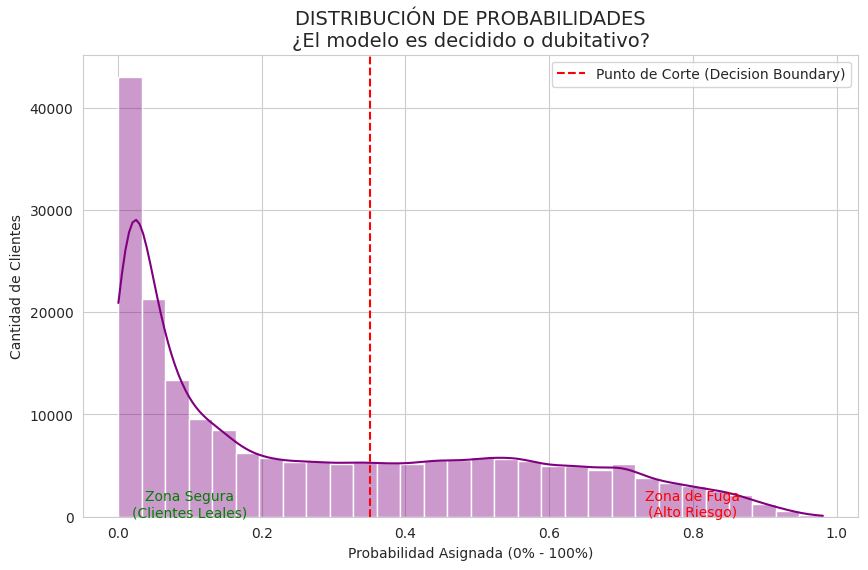

In [19]:
# --- GRÁFICO ACADÉMICO: DENSIDAD DE DISCRIMINACIÓN ---
plt.figure(figsize=(10, 6))

# Histograma del Riesgo
sns.histplot(df_analisis['Riesgo_Calculado'], kde=True, bins=30, color='purple', alpha=0.4)

plt.axvline(0.35, color='red', linestyle='--', label='Punto de Corte (Decision Boundary)')
plt.title('DISTRIBUCIÓN DE PROBABILIDADES\n¿El modelo es decidido o dubitativo?', fontsize=14)
plt.xlabel('Probabilidad Asignada (0% - 100%)')
plt.ylabel('Cantidad de Clientes')
plt.legend()

# Anotación de interpretación
plt.text(0.1, 10, 'Zona Segura\n(Clientes Leales)', color='green', ha='center')
plt.text(0.8, 10, 'Zona de Fuga\n(Alto Riesgo)', color='red', ha='center')

plt.show()

El análisis de densidad confirma que el modelo no actúa de manera aleatoria (lo que generaría una distribución plana o en forma de campana centrada en 0.5), sino que discrimina con fuerza.

Se observa una polarización deseable: el modelo acumula la gran masa de clientes en la zona de baja probabilidad (< 0.2), lo que evidencia una alta capacidad para filtrar 'Falsos Positivos'. Esto es crítico para la viabilidad financiera del proyecto, ya que asegura que los incentivos de retención se reserven exclusivamente para la 'cola larga' de la distribución (el segmento a la derecha del umbral de corte), maximizando así el ROI de cada intervención.